# Meta 1 – Análise Temporal e de Frequência

> **Projeto ATD 2025/2026** – Identificação de dígitos através de características extraídas de sinais de áudio.

---

In [33]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.io import wavfile
import matplotlib.pyplot as plt
import seaborn as sns

## Passos 1 & 2 – Estrutura de Dados e Importação dos Sinais de Áudio

Criação da estrutura de dados com os metadados de cada áudio (diretório, ficheiro, participante, dígito, repetição) e importação dos sinais `.wav` com a respetiva taxa de amostragem.

In [34]:
pasta_dados = '01'

def carregar_ficheiro(ficheiro, pasta_dados):
    
    caminho_completo = os.path.join(pasta_dados, ficheiro)
    componentes_nome = ficheiro.replace('.wav', '').split('_')
    
    if len(componentes_nome) != 3:
        return 1
    
    digito = int(componentes_nome[0])
    participante = componentes_nome[1]
    repeticao = int(componentes_nome[2])
    
    fs, sinal = wavfile.read(caminho_completo)
    
    return {
        'pasta_dados': pasta_dados,
        'ficheiro': ficheiro,
        'participante': participante,
        'digito': digito,
        'repeticao': repeticao,
        'taxa_amostragem': fs,
        'sinal': sinal
    }

dados_audio = []
for ficheiro in os.listdir(pasta_dados):
    if ficheiro.endswith('.wav'):
        novo = carregar_ficheiro(ficheiro, pasta_dados)
        if novo != 1:
            dados_audio.append(novo)

In [35]:
df = pd.DataFrame(dados_audio)
df = df.sort_values(by=['digito', 'repeticao']).reset_index(drop=True)
#display(df.head())

## Passo 3 – Representação Gráfica dos Sinais Originais

Visualização de um exemplo dos sinais importados, com o eixo horizontal em segundos, identificando o dígito e o número de repetição.

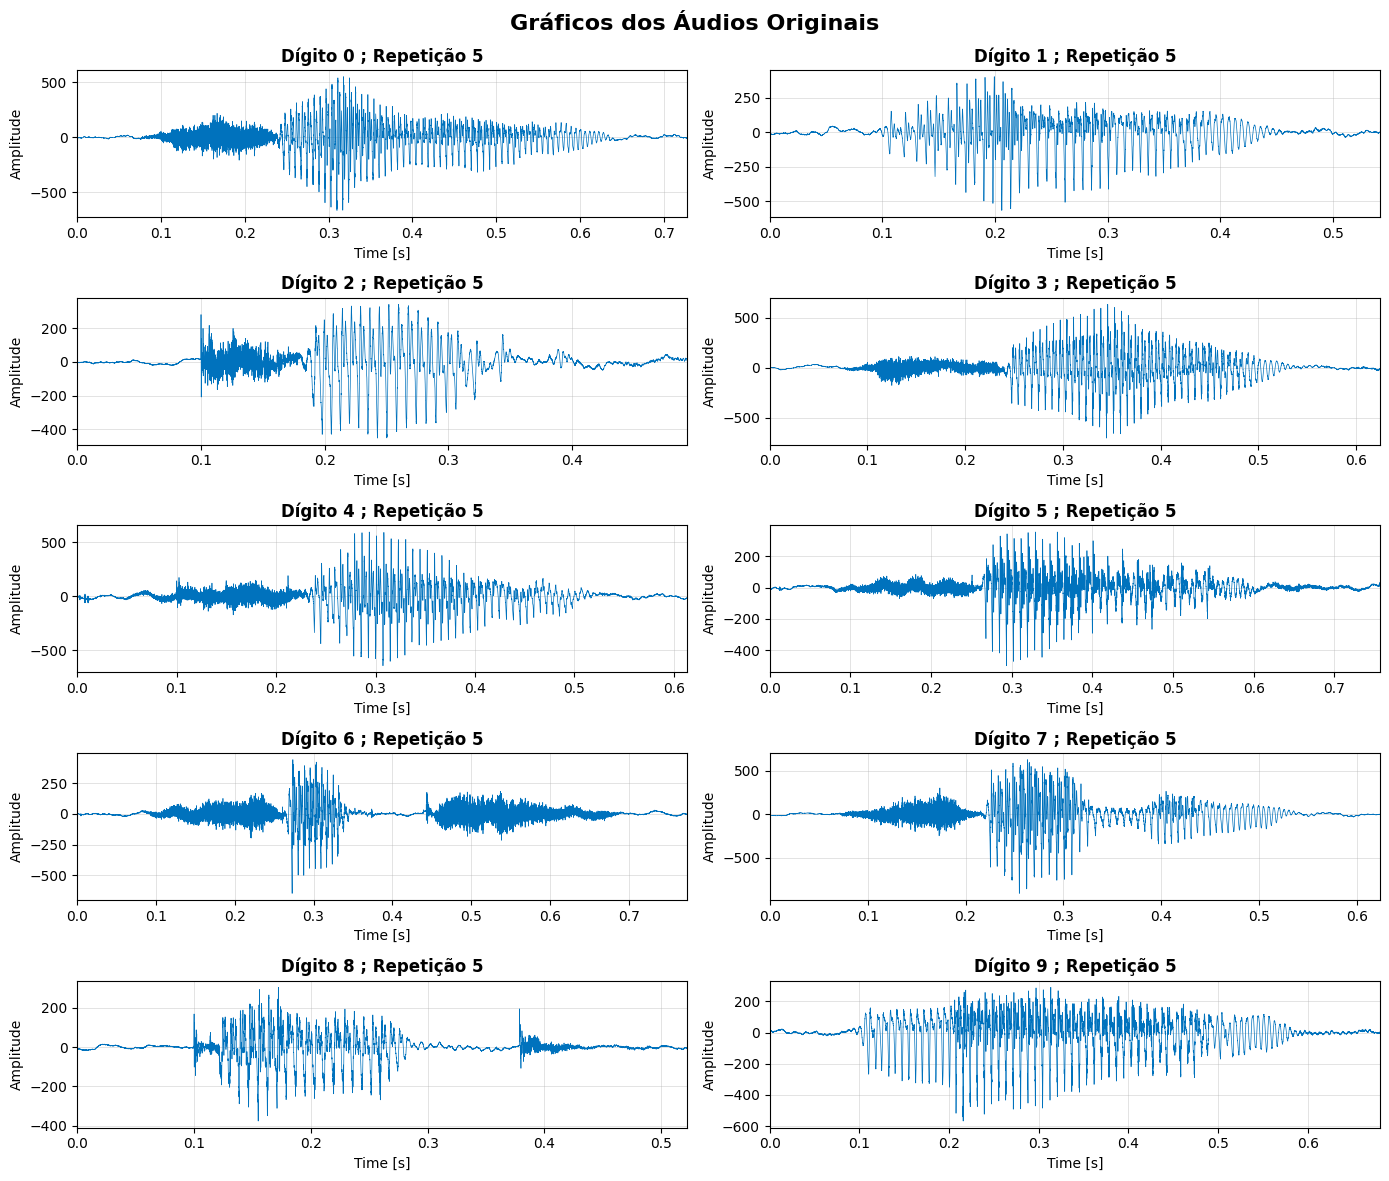

In [36]:
def plotar_sinais_audio(df_dados, coluna_sinal='sinal', titulo='Gráficos dos Áudios', repeticao=5):
    
    df_filtrado = df_dados[df_dados['repeticao'] == repeticao].sort_values(by='digito')
    
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 12))
    fig.suptitle(titulo, fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for i in range(len(axes)):#tambem podemos usar dois loops c/ 5 e 2
        ax=axes[i]
    
        if i < len(df_filtrado):
            linha = df_filtrado.iloc[i]
            sinal = linha[coluna_sinal]
            fs = linha['taxa_amostragem']
            digito = linha['digito']
            repeticao = linha['repeticao']
            
            tempo_segundos = np.arange(len(sinal)) / fs
            
            ax.plot(tempo_segundos, sinal, color='#0072BD', linewidth=0.5) 
            ax.set_title(f'Dígito {digito} ; Repetição {repeticao}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Time [s]')
            ax.set_ylabel('Amplitude')
            ax.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.5)
            ax.set_xlim([0, tempo_segundos[-1]])
            
    plt.tight_layout()
    fig.subplots_adjust(top=0.93)
    plt.show()

plotar_sinais_audio(df, 'sinal', 'Gráficos dos Áudios Originais')

## Passo 4 – Pré-processamento dos Sinais

Implementação dos seguintes passos de pré-processamento:
- **Remoção do silêncio inicial** – os sinais são alinhados temporalmente com base na energia;
- **Normalização da amplitude** – com base nos valores máximo e mínimo;
- **Equalização da duração** – adição ou remoção de silêncio no final para uniformizar a duração total.

In [37]:
def remover_silencio(sinal, razao_limiar=0.1,tamanho_janela=100):
    limiar = razao_limiar * np.max(np.abs(sinal))
    janela = np.ones(tamanho_janela) / tamanho_janela
    sinal_suavizado = np.convolve(np.abs(sinal), janela, mode='same')  #SUAVIZAR SINAL para tirar ruido antes e n so silencio
    i_ativos = np.where(sinal_suavizado > limiar)[0]
    
    if len(i_ativos) == 0:
        return sinal
    else:
        return sinal[i_ativos[0]:]
    
def normalizar_sinal(sinal): 
    minimo = np.min(sinal)
    maximo = np.max(sinal)
    return  2 * ((sinal - minimo) / (maximo - minimo)) - 1

def pre_processar_sinal(sinal):
    s_silencio = remover_silencio(sinal)
    normalizado = normalizar_sinal(s_silencio)
    return normalizado

In [38]:
s_processados = [pre_processar_sinal(s) for s in df['sinal']]

# adicionar silencio no fim
tamanho_maximo = max(len(s) for s in s_processados)
s_preenchidos = []

for s in s_processados:
    preenchimento = tamanho_maximo - len(s)
    preenchido = np.pad(s, (0, preenchimento), mode='constant', constant_values=0)
    s_preenchidos.append(preenchido)
df['sinal_pre_proc'] = s_preenchidos

## Passo 5 – Representação Gráfica dos Sinais Pré-processados

Repetição da representação gráfica do Passo 3, agora sobre os sinais após pré-processamento.

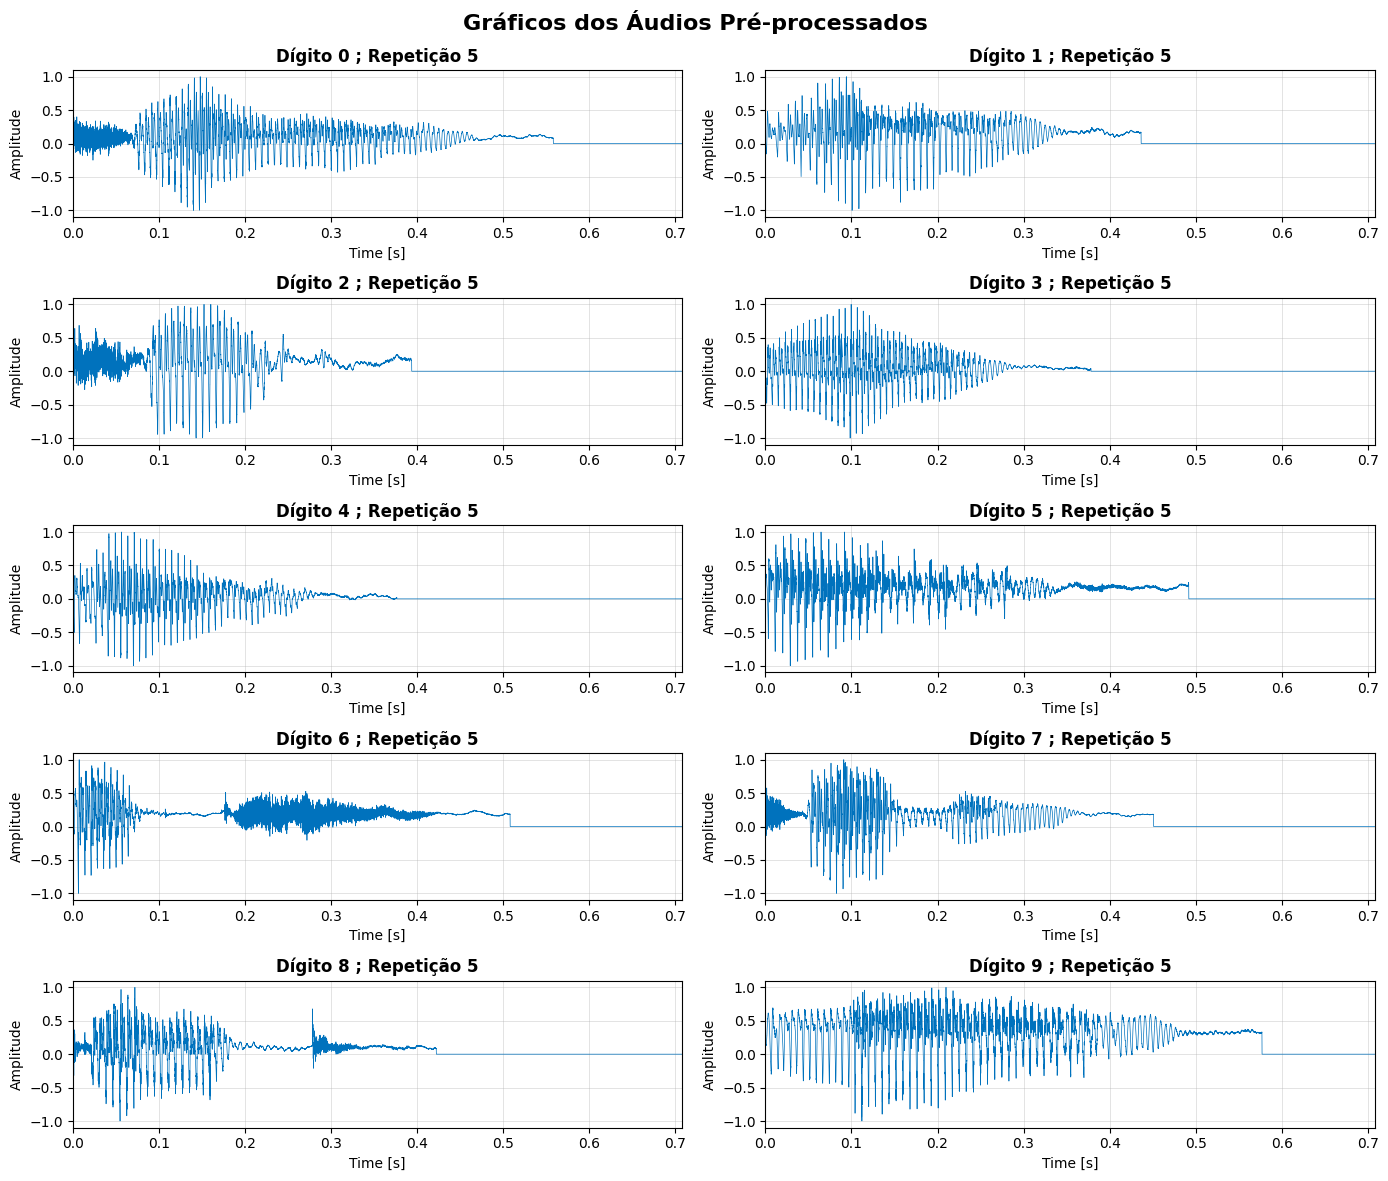

In [39]:
plotar_sinais_audio(df, coluna_sinal='sinal_pre_proc', titulo='Gráficos dos Áudios Pré-processados',repeticao=5)

## Passo 6 – Comparação Visual e Identificação de Características Temporais

Comparação entre os gráficos obtidos nos Passos 3 e 5, com identificação visual de possíveis características temporais que permitam diferenciar os dígitos.

Comparando os gráficos obtidos no 3 e no 5 constatamos que o processo de pré-processamento eliminou variabilidade irrelevante, garantido o mesmo instante de início do som, a mesma escala de amplitudes, e a mesma duração.

Conseguimos ainda identificar algumas características temporais nos gráficos que poderão ser usadas para distinguir os algarismos. Por exemplo: vemos que o número seis (Six) há um curto período a meio de quase silêncio durante o "i". Enquanto o nove (Nine) por um som contínuo sem grandes variações.


## Passo 7 – Cálculo de Características Temporais

Implementação e cálculo de 5 características temporais para cada sinal (energia total, cruzamentos por zero, valor eficaz, desvio padrão, razão energia), armazenadas na estrutura de dados.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. FUNÇÕES BASE
# =====================================================================
def energia_total(sinal):
    return np.sum(sinal ** 2)

def cruzamento_zero(sinal):
    alteracao_sinal = np.diff(np.sign(sinal))
    return np.sum(np.abs(alteracao_sinal))/2

def rms_energia(sinal):
    return np.sqrt(np.mean(sinal ** 2))

def razao_energia(sinal):
    meio = len(sinal) // 2
    primeira = np.sum(sinal[:meio]**2)
    segunda = np.sum(sinal[meio:]**2)
    if segunda == 0:
        return primeira
    return primeira / segunda

# =====================================================================
# 2. EXTRAÇÃO DE CARACTERÍSTICAS (GLOBAIS E FATIADAS)
# =====================================================================
n_fatias = 7
print(f"A extrair características temporais globais e fatiadas (em {n_fatias} janelas)...")

# Dicionários para guardar as listas
temporais_globais = {'energia_global': [], 'zcr_global': [], 'rms_global': [], 'std_global': [], 'razao_global': []}
temporais_fatiadas = {}

nomes_features_temp = ['energia', 'zcr', 'rms', 'std', 'razao']
for base in nomes_features_temp:
    for j in range(1, n_fatias + 1):
        temporais_fatiadas[f"{base}_w{j}"] = []

# Iterar sobre cada sinal
for sinal in df['sinal_pre_proc']:
    # A) Preencher as Globais (Sinal Inteiro)
    temporais_globais['energia_global'].append(energia_total(sinal))
    temporais_globais['zcr_global'].append(cruzamento_zero(sinal))
    temporais_globais['rms_global'].append(rms_energia(sinal))
    temporais_globais['std_global'].append(np.std(sinal))
    temporais_globais['razao_global'].append(razao_energia(sinal))
    
    # B) Preencher as Fatiadas (7 pedaços)
    fatias = np.array_split(sinal, n_fatias)
    for j in range(n_fatias):
        fatia_atual = fatias[j]
        temporais_fatiadas[f"energia_w{j+1}"].append(energia_total(fatia_atual))
        temporais_fatiadas[f"zcr_w{j+1}"].append(cruzamento_zero(fatia_atual))
        temporais_fatiadas[f"rms_w{j+1}"].append(rms_energia(fatia_atual))
        temporais_fatiadas[f"std_w{j+1}"].append(np.std(fatia_atual))
        temporais_fatiadas[f"razao_w{j+1}"].append(razao_energia(fatia_atual))

# Atualizar o DataFrame
for nome, valores in temporais_globais.items():
    df[nome] = valores
for nome, valores in temporais_fatiadas.items():
    df[nome] = valores

print("Estrutura de dados atualizada! A gerar gráficos...")

A extrair características temporais globais e fatiadas (em 7 janelas)...
Estrutura de dados atualizada! A gerar gráficos...


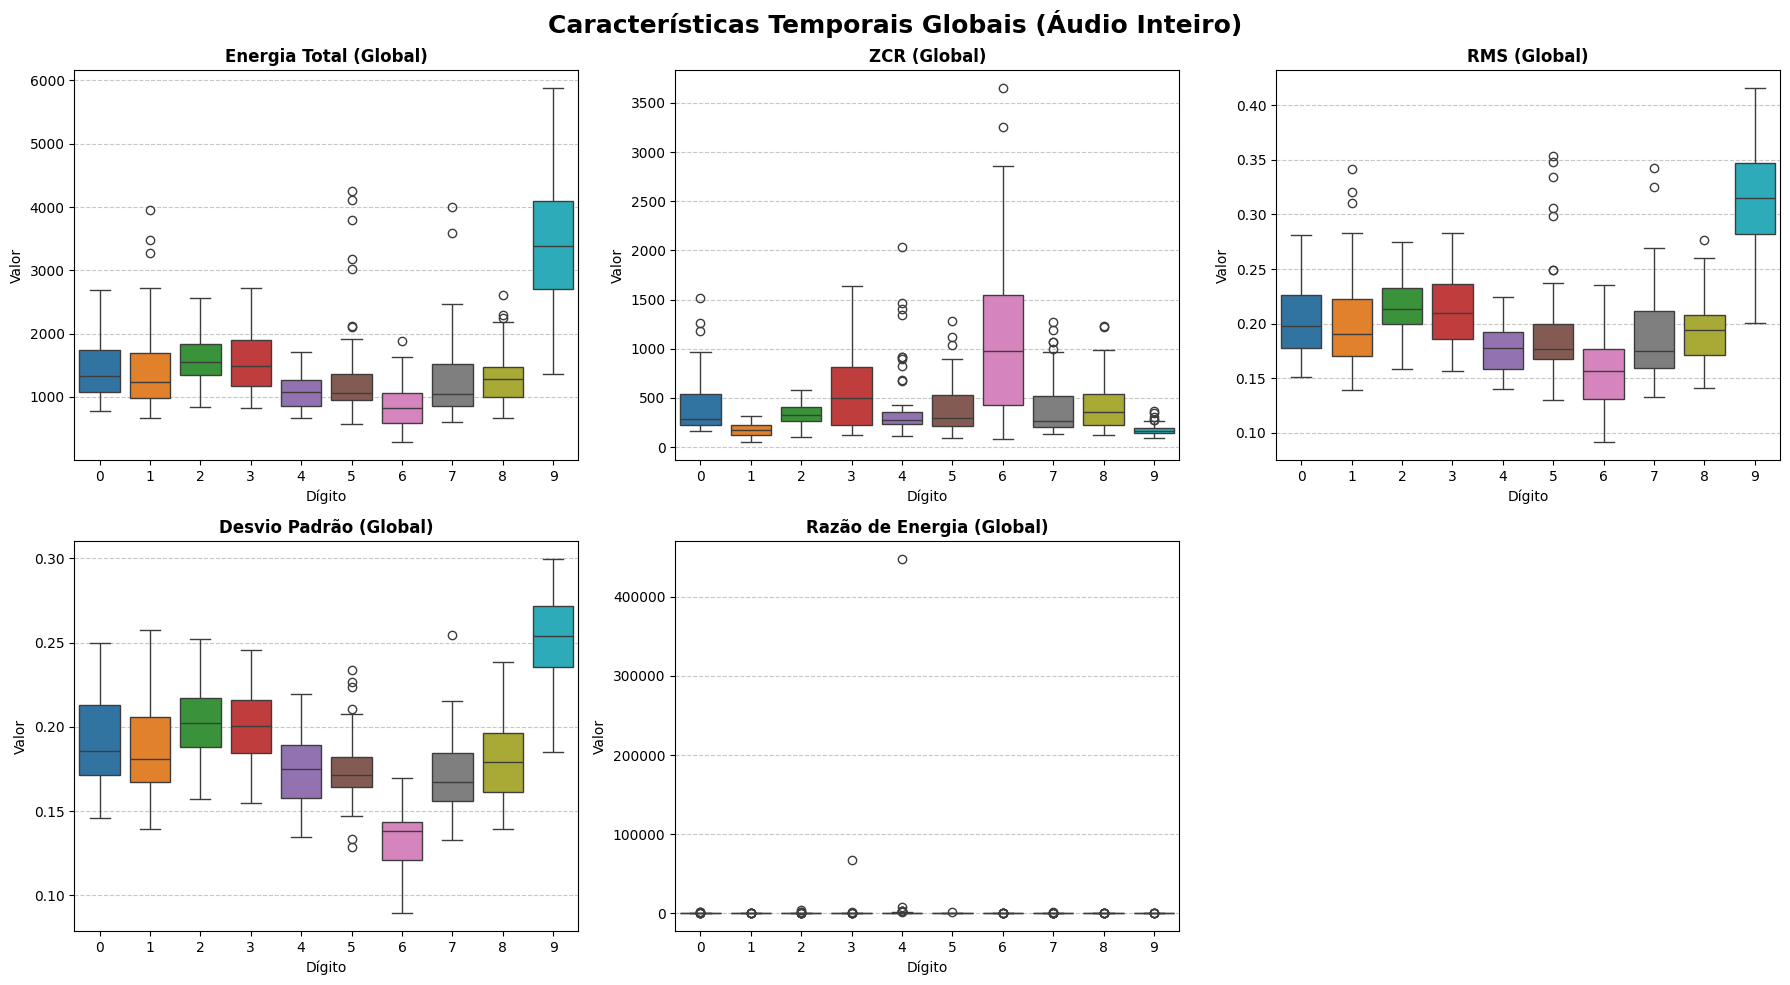

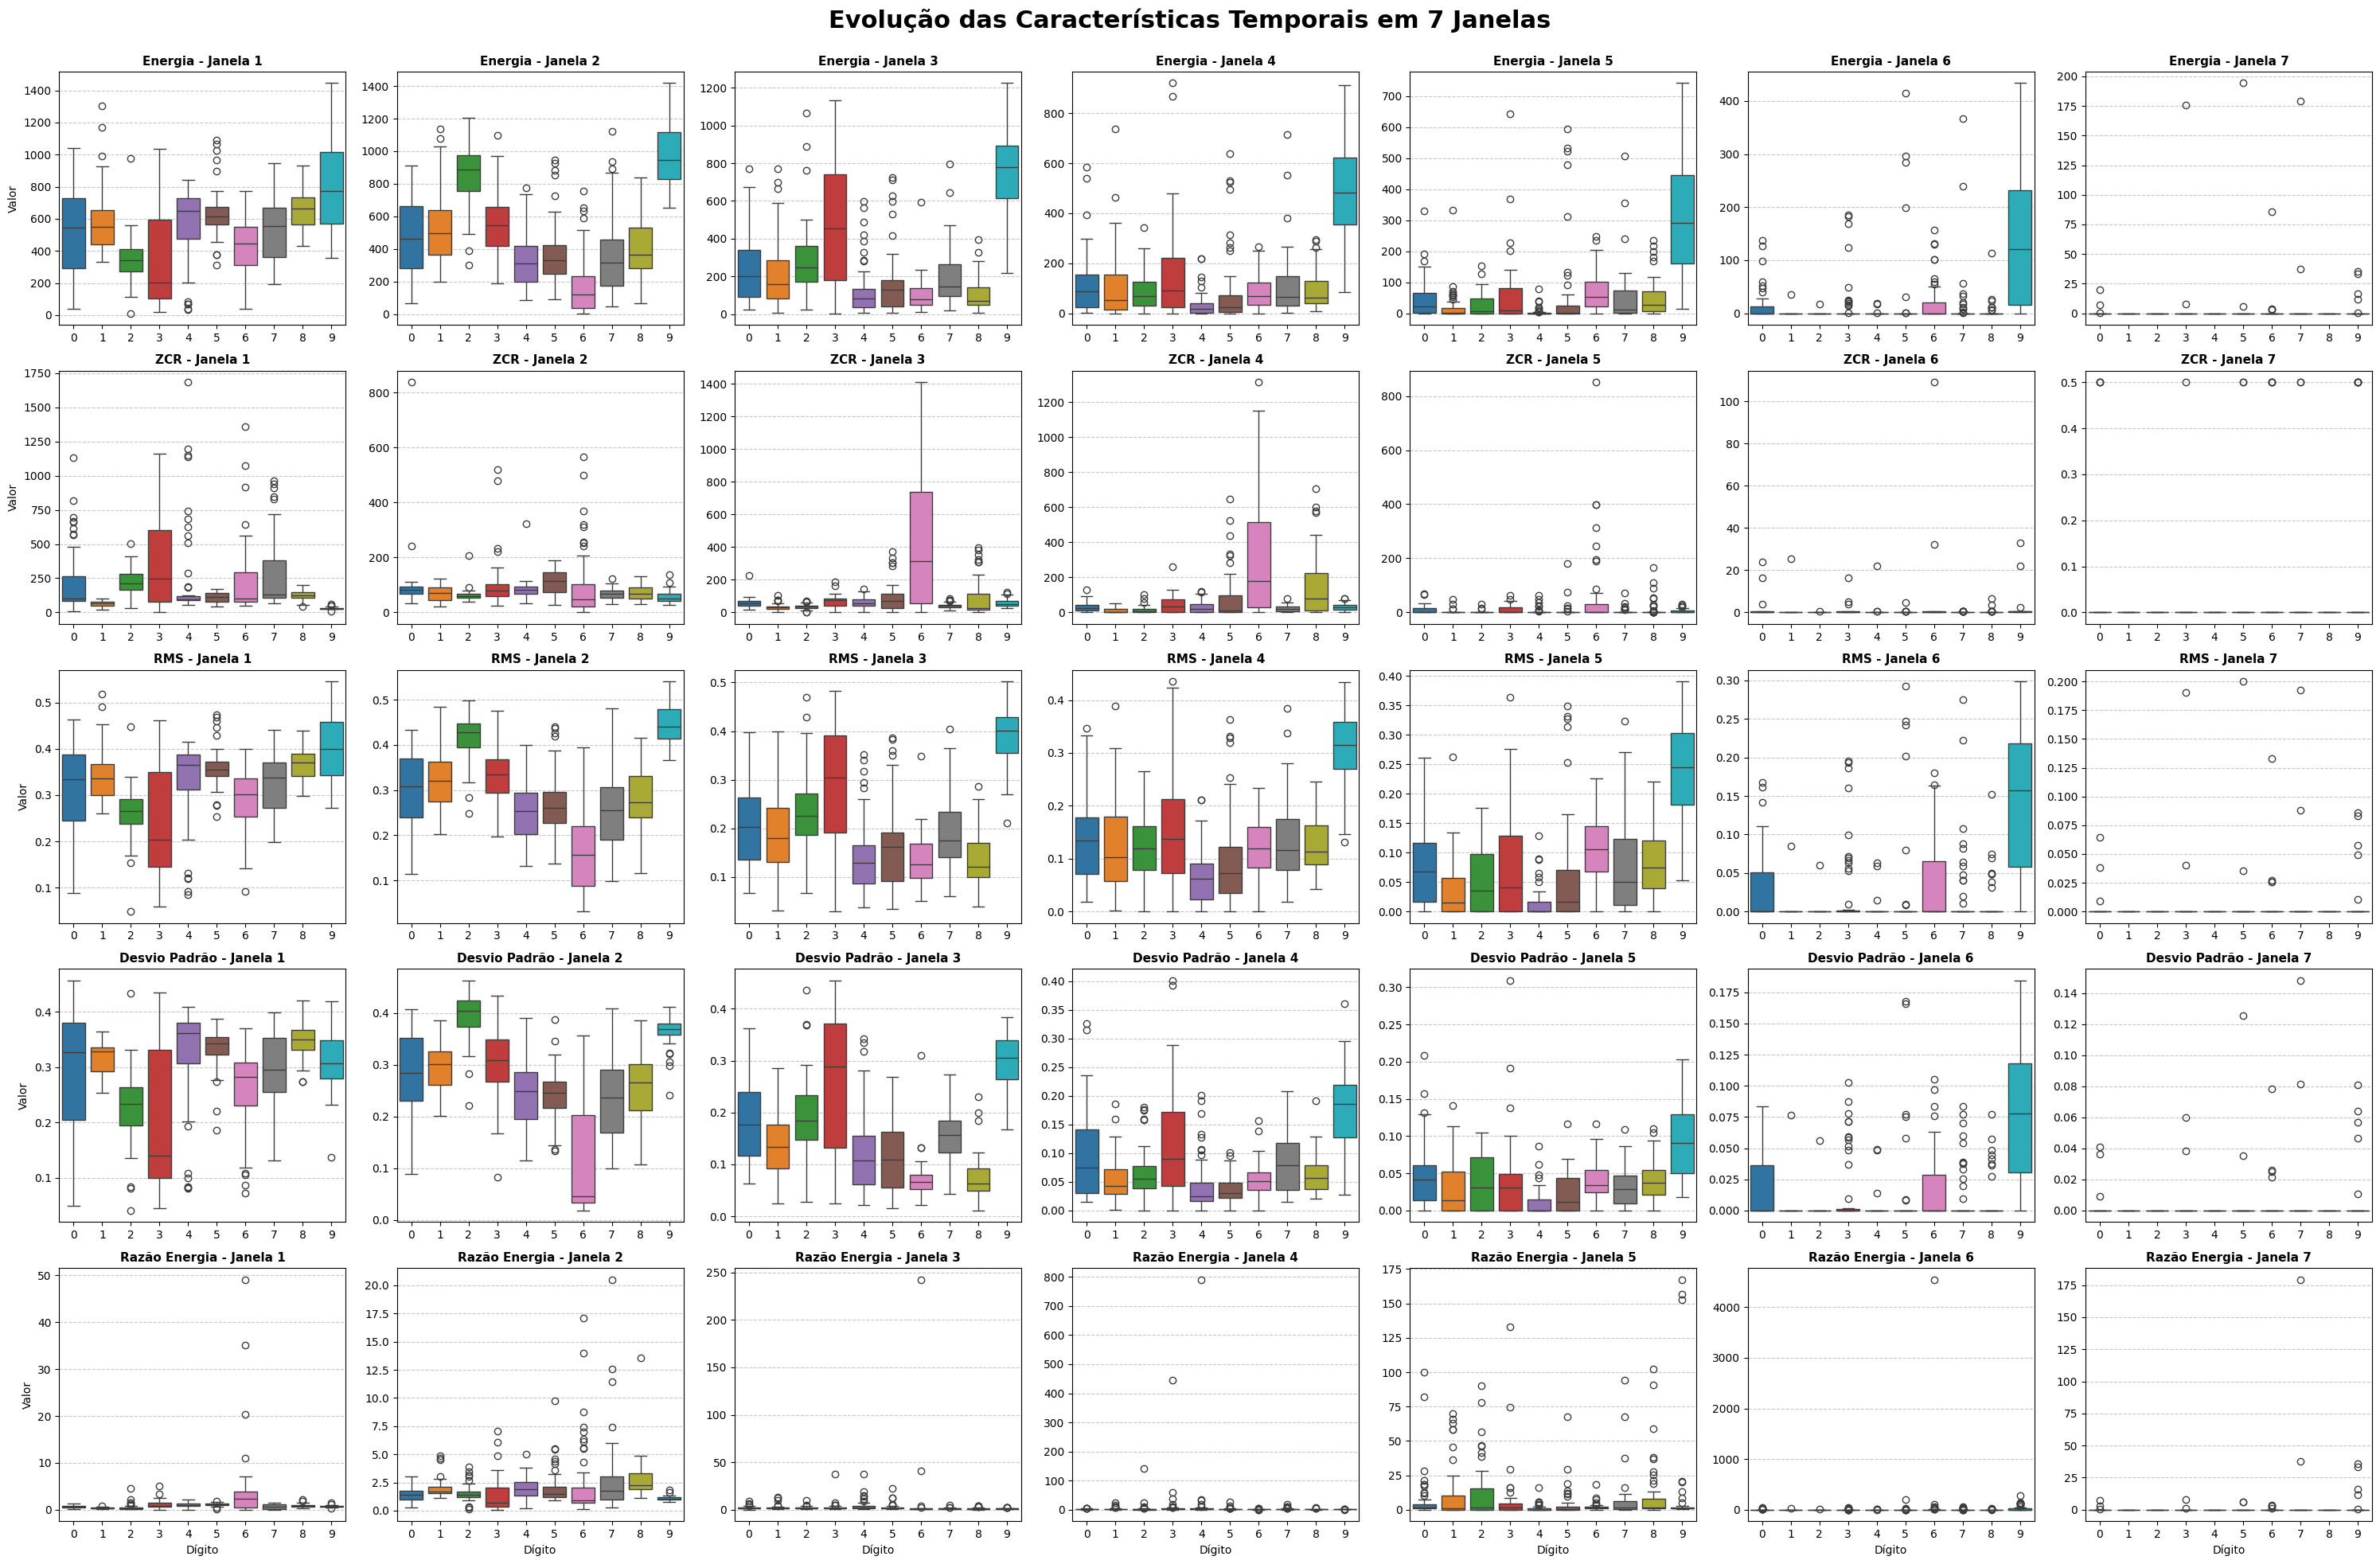

In [41]:
paleta = sns.color_palette("tab10", 10)
colunas_globais = list(temporais_globais.keys())
titulos_globais = ['Energia Total (Global)', 'ZCR (Global)', 'RMS (Global)', 
                   'Desvio Padrão (Global)', 'Razão de Energia (Global)']

fig_g, axes_g = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig_g.suptitle('Características Temporais Globais (Áudio Inteiro)', fontsize=18, fontweight='bold')
axes_g = axes_g.flatten()

for i in range(len(colunas_globais)):
    sns.boxplot(x='digito', y=colunas_globais[i], data=df, ax=axes_g[i], hue='digito', palette=paleta, legend=False)
    axes_g[i].set_title(titulos_globais[i], fontweight='bold')
    axes_g[i].set_xlabel('Dígito')
    axes_g[i].set_ylabel('Valor')
    axes_g[i].grid(axis='y', linestyle='--', alpha=0.7)

axes_g[5].set_visible(False) # Esconder o último gráfico vazio
plt.tight_layout()
fig_g.subplots_adjust(top=0.92)
plt.show()

# =====================================================================
# 4. REPRESENTAÇÃO GRÁFICA 2: FATIADAS (5x7 JANELAS)
# =====================================================================
fig_f, axes_f = plt.subplots(nrows=5, ncols=n_fatias, figsize=(30, 20))
fig_f.suptitle('Evolução das Características Temporais em 7 Janelas', fontsize=22, fontweight='bold')

titulos_y = ['Energia', 'ZCR', 'RMS', 'Desvio Padrão', 'Razão Energia']

for lin, base in enumerate(nomes_features_temp):
    for col in range(n_fatias):
        nome_feature = f"{base}_w{col+1}"
        ax = axes_f[lin, col]
        
        sns.boxplot(x='digito', y=nome_feature, data=df, ax=ax, hue='digito', palette=paleta, legend=False)
        ax.set_title(f"{titulos_y[lin]} - Janela {col+1}", fontweight='bold', fontsize=11)
        
        # Limpar rótulos para não sobrecarregar visualmente
        if lin == 4:
            ax.set_xlabel('Dígito')
        else:
            ax.set_xlabel('')
            
        if col == 0:
            ax.set_ylabel('Valor')
        else:
            ax.set_ylabel('')
            
        ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
fig_f.subplots_adjust(top=0.94)
plt.show()

## Passo 8 – Seleção das Melhores Características Temporais

Seleção das 3 características temporais mais discriminativas entre dígitos e visualização

 Energia Janela 2: separa alguns digitos
 RMS janela 6: deteta os digitos que duram mais tempo 0,6,9
 ZCR Janela 1: deteta osque começam com consoantes mais ruidosascomo o 3 e o 0

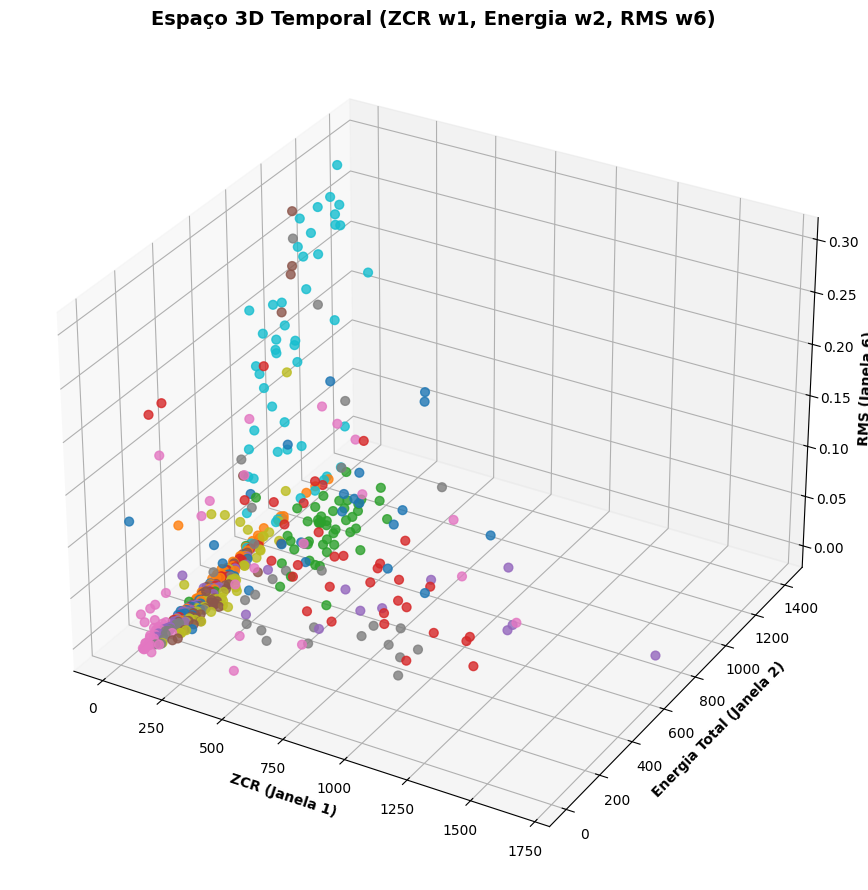

In [42]:
import matplotlib.pyplot as plt

# Criar a figura
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# As 3 características temporais fatiadas que selecionou
x = df['zcr_w1']
y = df['energia_w2']
z = df['rms_w6']

# Desenhar o gráfico de dispersão 3D
scatter = ax.scatter(x, y, z, c=df['digito'], cmap='tab10', s=40, alpha=0.8)

# Rótulos dos eixos com as respetivas janelas
ax.set_xlabel('ZCR (Janela 1)', fontweight='bold')
ax.set_ylabel('Energia Total (Janela 2)', fontweight='bold')
ax.set_zlabel('RMS (Janela 6)', fontweight='bold')
ax.set_title('Espaço 3D Temporal (ZCR w1, Energia w2, RMS w6)', fontsize=14, fontweight='bold')

# Adicionar legenda (ajustada para ficar bem enquadrada)
legend = ax.legend(*scatter.legend_elements(), title="Dígitos", loc='upper left', bbox_to_anchor=(1.05, 1))
ax.add_artist(legend)

# Guardar e mostrar
plt.tight_layout()
plt.savefig('grafico_3d_temporais.png', dpi=300)
plt.show()

## Passo 9 & 10 – Coeficientes da Série Complexa de Fourier e Cálculo do Espetro de Amplitude

**Passo 9:** Cálculo dos coeficientes da DFT (via `np.fft.fft`) para cada sinal pré-processado

**Passo 10:** Cálculo do espetro de amplitude mediano normalizado (por dígito), incluindo o 1.º quartil (25%) e o 3.º quartil (75%), apenas para frequências positivas

Observa-se que, apesar de a energia se concentrar predominantemente nas baixas frequências, o espetro de amplitude mediano permite distinguir claramente os diferentes dígitos analisados:

Amplitude máxima: Audios como o "1", "2", "3", "8" e "9" têm um primeiro pico muito alto, ultrapassando os 0.02, que os distingue dos restantes.

Disperção: É possível testemunhar que nos dígitos "2", "6" e "8" temos uma largura de banda/disperção maior, com ocorrências significativas após os 3000Hz, o que não acontece nos outros.

Formato geral: Antes dos 2000Hz verificamos que os dígitos "1", "4", "5" e "9" têm uma queda suave/constante da sua amplitude, o que salta à vista quando comparado com as quedas repentinas mais comuns.

Coefecientes guardados na coluna 'fft_coefs'


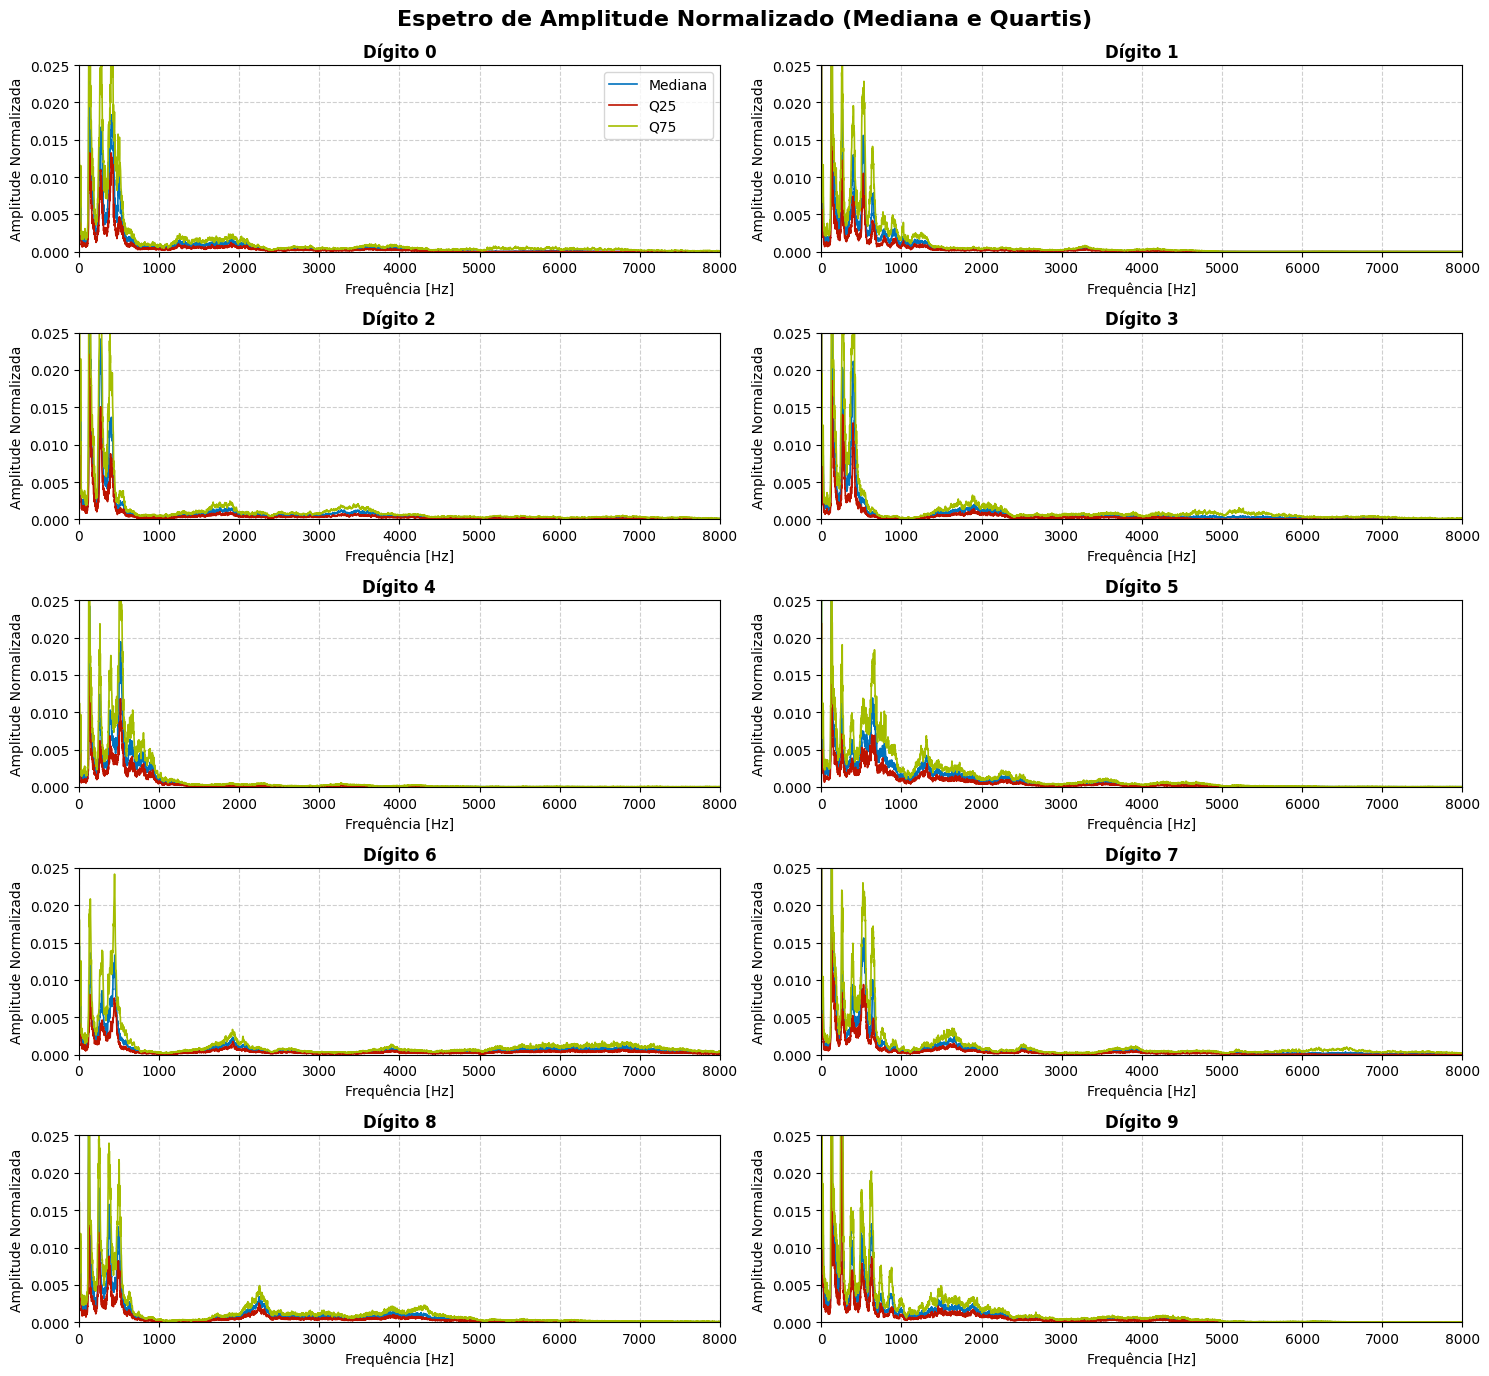

In [43]:

df['fft_coefs']=[np.fft.fft(s) for s in df['sinal_pre_proc']]
print("Coefecientes guardados na coluna 'fft_coefs'")
#display(df[['digito', 'repeticao', 'fft_coefs']].head())

N = len(df['sinal_pre_proc'].iloc[0])
fs = df['taxa_amostragem'].iloc[0]
meio_N = N//2
eixo_freqs = np.linspace(0 ,fs/2, meio_N)

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 14))
fig.suptitle('Espetro de Amplitude Normalizado (Mediana e Quartis)', fontsize=16, fontweight='bold')
axes = axes.flatten()

stats_espetrais = {}

for digito in range(10):
    df_digito = df[df['digito']==digito]
    
    espetros_pos=[]
    for fft_array in df_digito['fft_coefs']:
        amplitude = np.abs(fft_array)/N
        lado_pos=amplitude[:meio_N]    #Duplicar coeficientes metade positiva
        lado_pos[1:]=2*lado_pos[1:]
        espetros_pos.append(lado_pos)
        
    matriz_espetros = np.array(espetros_pos)
    
    q1=np.quantile(matriz_espetros, 0.25, axis=0)
    mediana=np.quantile(matriz_espetros, 0.5, axis=0)
    q3=np.quantile(matriz_espetros, 0.75, axis=0)
    
    stats_espetrais[digito] = {'q1':q1, 'mediana':mediana, 'q3': q3}
    
    ax = axes[digito]
    
    ax.plot(eixo_freqs, mediana, color='#0072BD', linewidth=1.2, label='Mediana')    
    ax.plot(eixo_freqs, q1, color="#BD1300", linewidth=1.2, label='Q25')  
    ax.plot(eixo_freqs, q3, color="#A4BD00", linewidth=1.2, label='Q75')  
    
    ax.set_title(f'Dígito {digito}', fontweight='bold')
    ax.set_xlabel('Frequência [Hz]')
    ax.set_ylabel('Amplitude Normalizada')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim([0, 8000])
    ax.set_ylim([0, 0.025])
    
    if digito == 0:
        ax.legend()

plt.tight_layout()
fig.subplots_adjust(top=0.94)
plt.show()

## Passo 11 – Características Espetrais

Cálculo de 5 características espetrais para cada sinal (frequência dominante, amplitude máxima espetral, média espetral, centroide espetral, frequência de borda espetral).

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft

# =====================================================================
# 1. FUNÇÃO DE EXTRAÇÃO (Baseada no seu código original)
# =====================================================================
def calcular_espetrais(sinal, fs):
    """Calcula as suas 5 características espetrais para qualquer sinal ou fatia."""
    N = len(sinal)
    meio_N = N // 2
    
    # Se a fatia for demasiado pequena ou vazia
    if N == 0: return 0, 0, 0, 0, 0
    
    # Calcular FFT da fatia
    fft_array = fft(sinal)
    amp_norm = np.abs(fft_array[:meio_N]) / N
    eixo_freqs = np.linspace(0, fs/2, meio_N)
    
    total_amp = np.sum(amp_norm)
    if total_amp == 0: # Prevenir divisão por zero no silêncio
        return 0, 0, 0, 0, 0
        
    indice_max = np.argmax(amp_norm)
    freq_dom = eixo_freqs[indice_max]
    amp_max = amp_norm[indice_max]
    media_esp = np.mean(amp_norm)
    
    centroide = np.sum(eixo_freqs * amp_norm) / total_amp
    
    energia_acumulada = np.cumsum(amp_norm ** 2)
    energia_total = energia_acumulada[-1]
    
    # Prevenção de erro caso a energia seja nula
    if energia_total == 0:
        edge_freq = 0
    else:
        indice_edge = np.where(energia_acumulada >= 0.95 * energia_total)[0][0]
        edge_freq = eixo_freqs[indice_edge]
        
    return freq_dom, amp_max, media_esp, centroide, edge_freq

# =====================================================================
# 2. EXTRAÇÃO PARA O DATAFRAME
# =====================================================================
n_fatias = 7
print(f"A calcular as 5 características espetrais (Globais e em {n_fatias} Janelas)...")

espetrais_globais = {'freq_dominante_g': [], 'amp_max_g': [], 'media_espetral_g': [], 'centroide_g': [], 'edge_freq_g': []}
espetrais_fatiadas = {}
nomes_features_esp = ['freq_dom', 'amp_max', 'media_esp', 'centroide', 'edge_freq']

for base in nomes_features_esp:
    for j in range(1, n_fatias + 1):
        espetrais_fatiadas[f"{base}_w{j}"] = []

# Iterar sobre cada sinal da estrutura
for i in range(len(df)):
    sinal = df.iloc[i]['sinal_pre_proc']
    
    # RECUPERAR A FREQUÊNCIA DE AMOSTRAGEM (fs)
    # ATENÇÃO: Se não tiver a coluna 'fs' no DataFrame, substitua a linha abaixo 
    # pelo seu valor global (ex: fs_atual = fs_global ou fs_atual = 22050)
    fs_atual = df.iloc[i]['fs'] if 'fs' in df.columns else 22050 
    
    # A) Calcular Globais (Sinal Inteiro)
    f_dom, a_max, m_esp, cent, e_freq = calcular_espetrais(sinal, fs_atual)
    espetrais_globais['freq_dominante_g'].append(f_dom)
    espetrais_globais['amp_max_g'].append(a_max)
    espetrais_globais['media_espetral_g'].append(m_esp)
    espetrais_globais['centroide_g'].append(cent)
    espetrais_globais['edge_freq_g'].append(e_freq)
    
    # B) Calcular Fatiadas (7 Janelas)
    fatias = np.array_split(sinal, n_fatias)
    for j in range(n_fatias):
        f_dom_w, a_max_w, m_esp_w, cent_w, e_freq_w = calcular_espetrais(fatias[j], fs_atual)
        espetrais_fatiadas[f"freq_dom_w{j+1}"].append(f_dom_w)
        espetrais_fatiadas[f"amp_max_w{j+1}"].append(a_max_w)
        espetrais_fatiadas[f"media_esp_w{j+1}"].append(m_esp_w)
        espetrais_fatiadas[f"centroide_w{j+1}"].append(cent_w)
        espetrais_fatiadas[f"edge_freq_w{j+1}"].append(e_freq_w)

# Guardar as novas características no DataFrame
for nome, valores in espetrais_globais.items(): df[nome] = valores
for nome, valores in espetrais_fatiadas.items(): df[nome] = valores

print("Estrutura atualizada! A gerar os gráficos...")

A calcular as 5 características espetrais (Globais e em 7 Janelas)...
Estrutura atualizada! A gerar os gráficos...


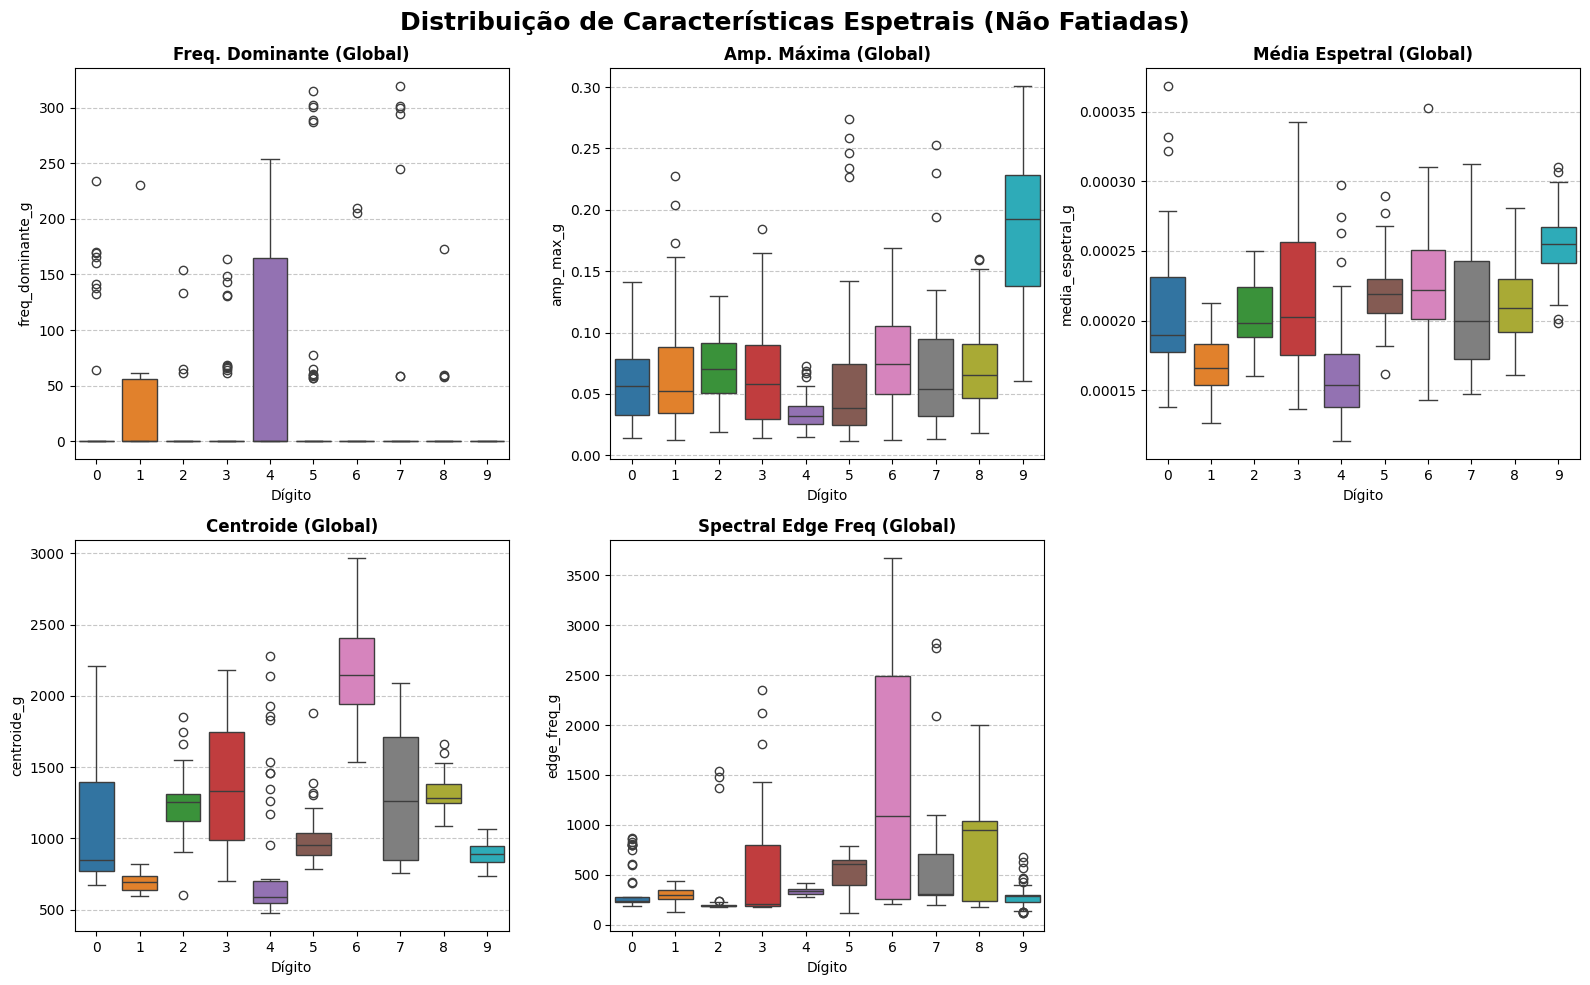

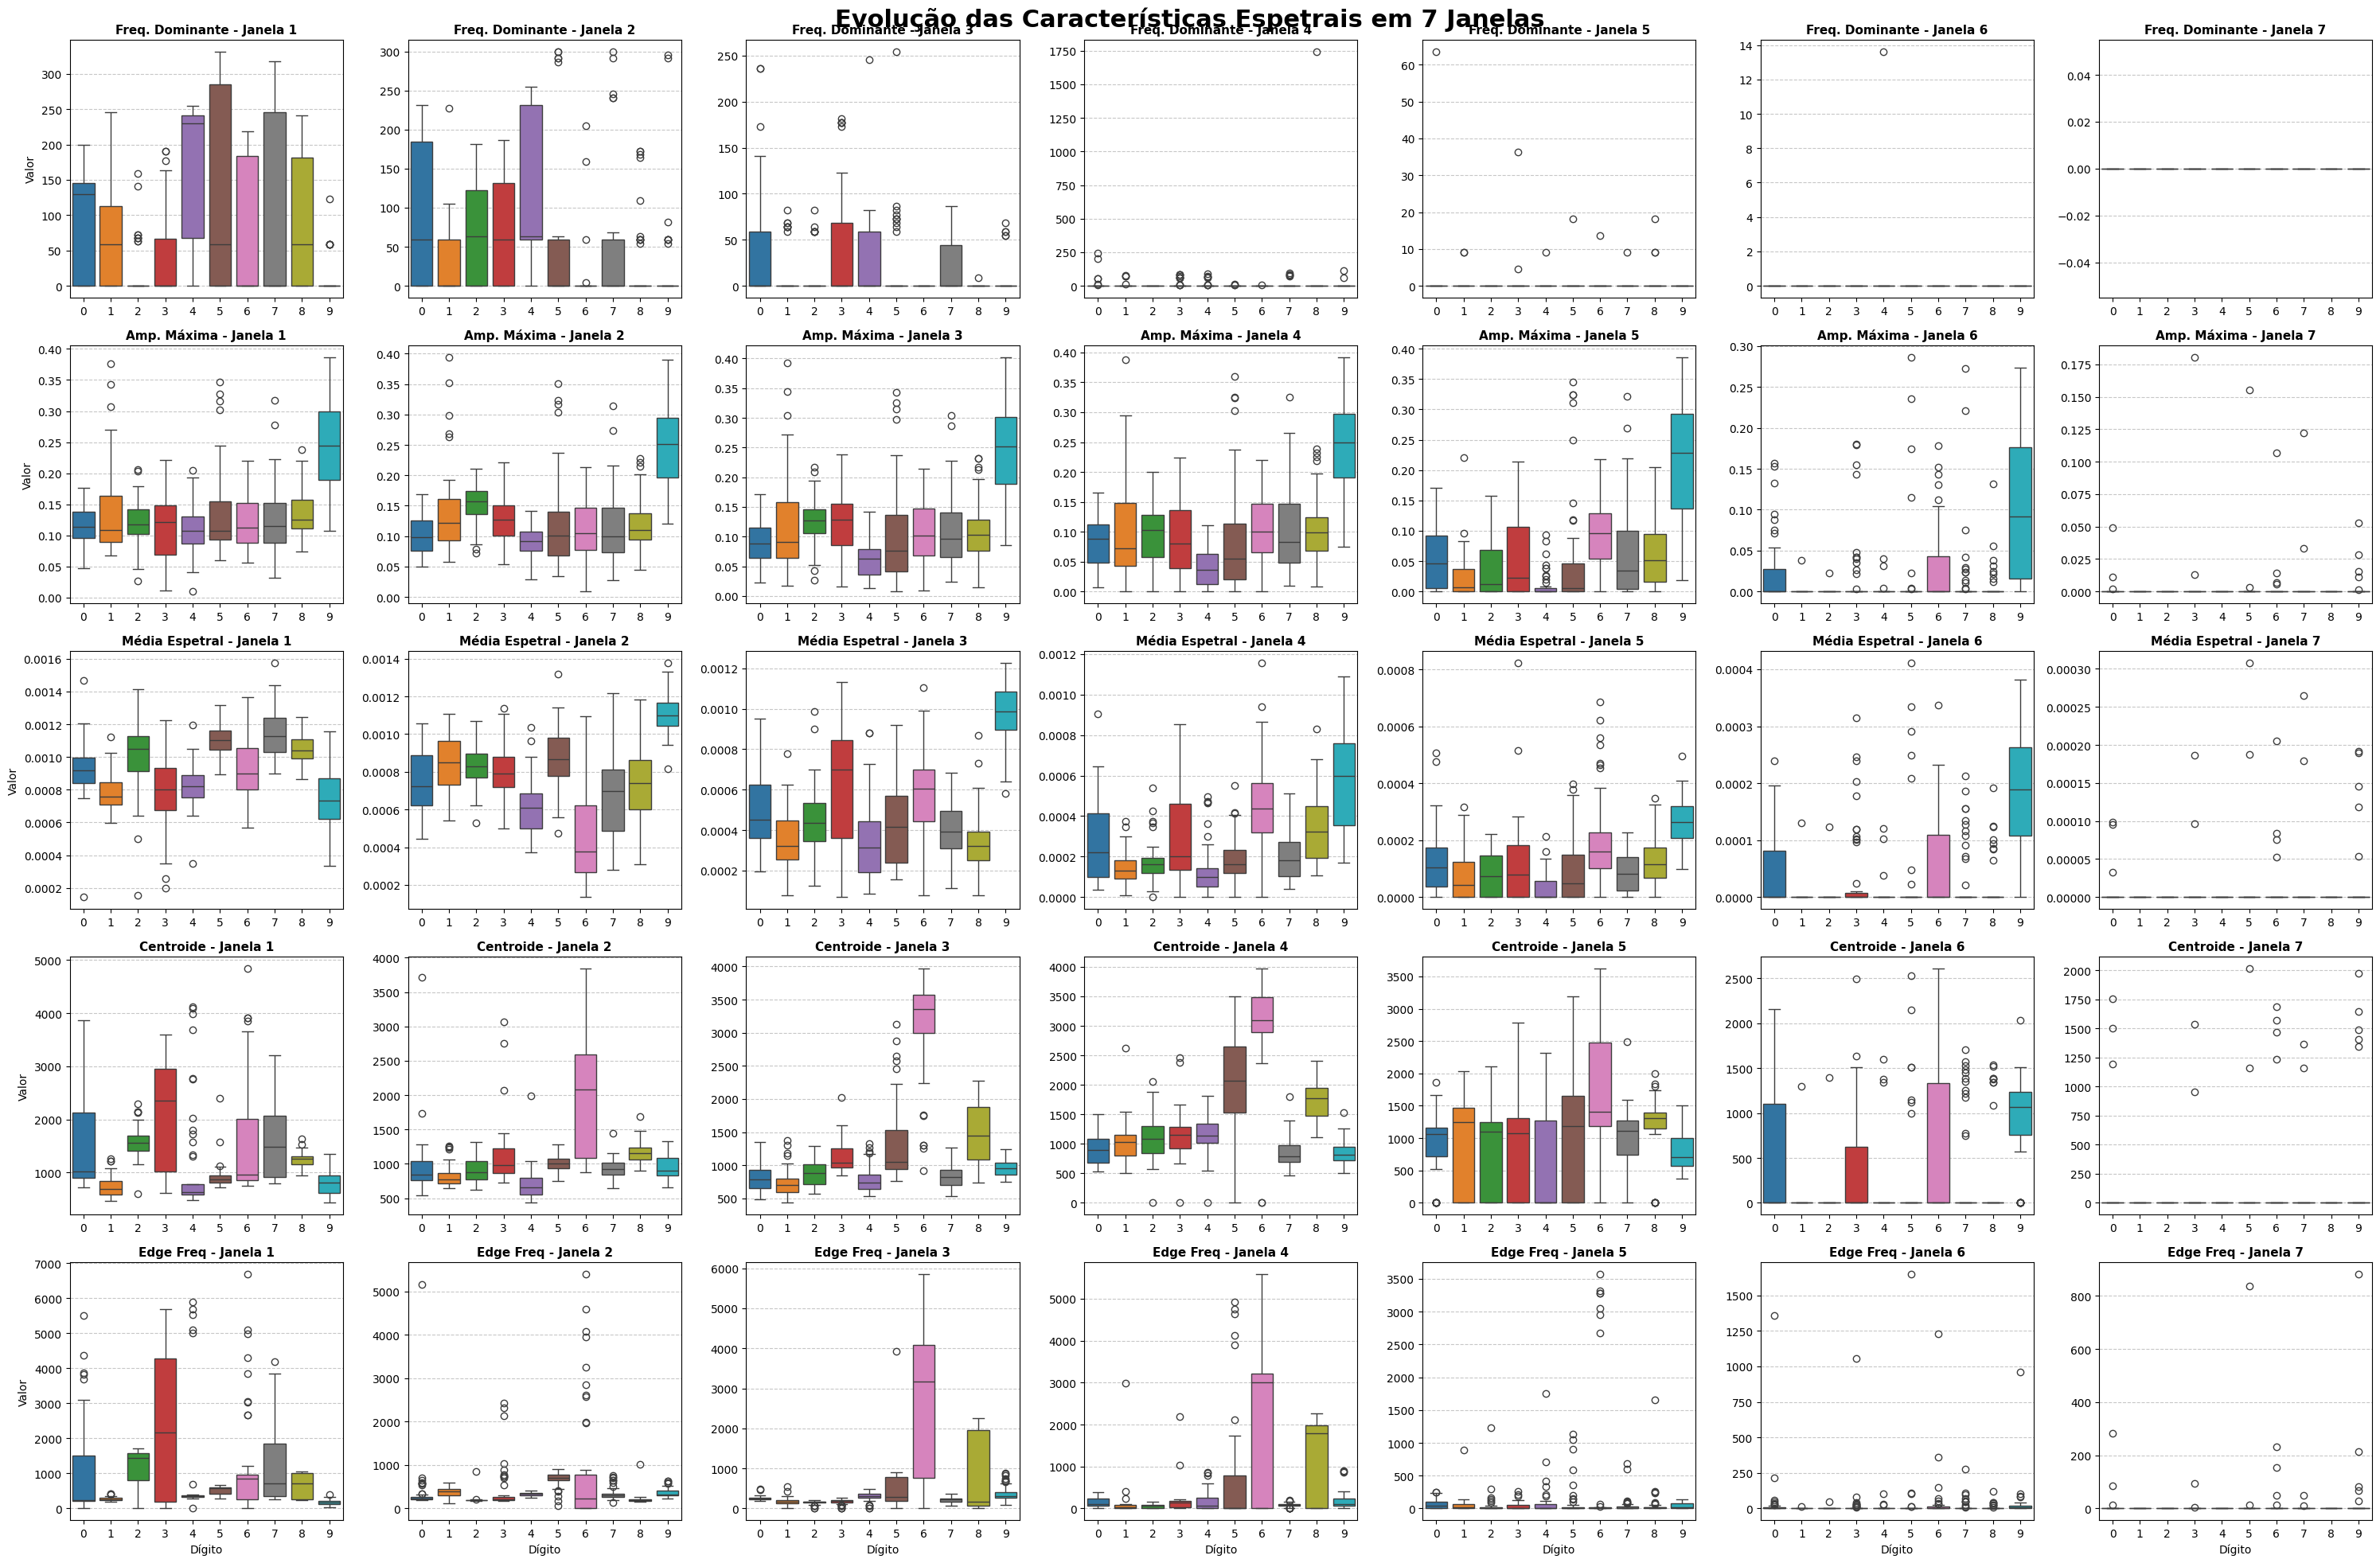

In [45]:
paleta = sns.color_palette("tab10", 10)

# --- GRÁFICO 1: BOXPLOTS GLOBAIS (Não Fatiados) ---
colunas_globais = list(espetrais_globais.keys())
titulos_globais = ['Freq. Dominante (Global)', 'Amp. Máxima (Global)', 
                   'Média Espetral (Global)', 'Centroide (Global)', 'Spectral Edge Freq (Global)']

fig_g, axes_g = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
fig_g.suptitle('Distribuição de Características Espetrais (Não Fatiadas)', fontsize=18, fontweight='bold')
axes_g = axes_g.flatten()

for i in range(len(colunas_globais)):
    sns.boxplot(x='digito', y=colunas_globais[i], data=df, ax=axes_g[i], hue='digito', palette=paleta, legend=False)
    axes_g[i].set_title(titulos_globais[i], fontweight='bold')
    axes_g[i].set_xlabel('Dígito')
    axes_g[i].grid(axis='y', linestyle='--', alpha=0.7)

axes_g[5].set_visible(False)
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: BOXPLOTS FATIADOS (5x7) ---
fig_f, axes_f = plt.subplots(nrows=5, ncols=n_fatias, figsize=(30, 20))
fig_f.suptitle('Evolução das Características Espetrais em 7 Janelas', fontsize=22, fontweight='bold')
titulos_fatiadas = ['Freq. Dominante', 'Amp. Máxima', 'Média Espetral', 'Centroide', 'Edge Freq']

for lin, base in enumerate(nomes_features_esp):
    for col in range(n_fatias):
        nome_feature = f"{base}_w{col+1}"
        ax = axes_f[lin, col]
        
        sns.boxplot(x='digito', y=nome_feature, data=df, ax=ax, hue='digito', palette=paleta, legend=False)
        ax.set_title(f"{titulos_fatiadas[lin]} - Janela {col+1}", fontweight='bold', fontsize=11)
        
        if lin == 4: ax.set_xlabel('Dígito')
        else: ax.set_xlabel('')
        if col == 0: ax.set_ylabel('Valor')
        else: ax.set_ylabel('')
            
        ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



## Passo 12 – Seleção das Melhores Características Espetrais

Seleção das 3 características espetrais mais discriminativas entre dígitos e visualização

Centroide Espetral Global: Esta feature representa o "centro de massa" do espetro, sendo que se observam distribuições de energia em diferentes frequências, criando um ótimo contraste quando comparado com outras caraterísticas.

Média Espetral Janela 1: A média espetral dá-nos uma ideia da energia média ao longo de todo o espetro. Isto possibilita distinguir dígitos com diferentes padrões de energia, o que ajuda a reiterar as diferenças entre os áudios. ALTERAR PARA JANELA 1

Edge freq janela 1: EXPLICAR

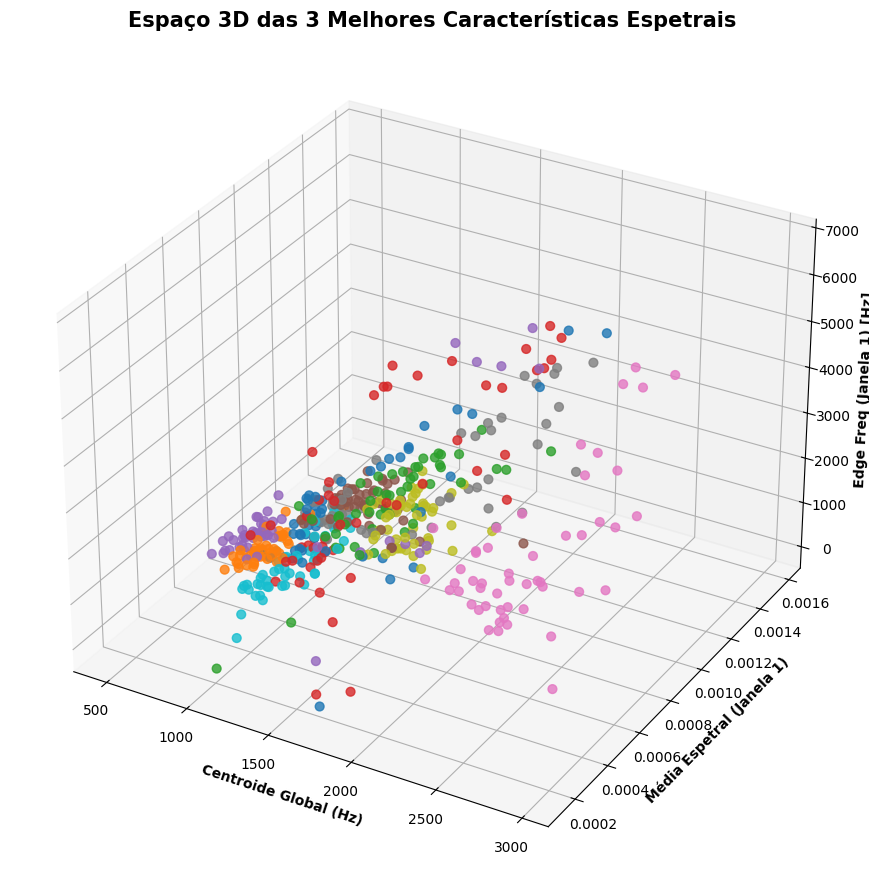

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definir as 3 variáveis exatas baseadas nas colunas geradas anteriormente
f1 = 'centroide_g'      # Centroide Espetral (Global)
f2 = 'media_esp_w1'     # Média Espetral (Janela 1)
f3 = 'edge_freq_w1'     # Spectral Edge Frequency (Janela 1)

# 2. Preparar as cores baseadas nas classes dos dígitos
cores = pd.Categorical(df['digito']).codes

# 3. Desenhar o Gráfico 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot: Usar a paleta 'tab10' que tem 10 cores perfeitamente distinguíveis
scatter = ax.scatter(df[f1], df[f2], df[f3], 
                     c=cores, cmap='tab10', s=40, alpha=0.8)

# 4. Títulos e Rótulos dos Eixos bem legíveis
ax.set_xlabel('Centroide Global (Hz)', fontweight='bold')
ax.set_ylabel('Média Espetral (Janela 1)', fontweight='bold')
ax.set_zlabel('Edge Freq (Janela 1) [Hz]', fontweight='bold')
ax.set_title('Espaço 3D das 3 Melhores Características Espetrais', fontsize=15, fontweight='bold')

# 5. Adicionar a Legenda (colocada do lado de fora para não tapar os pontos)
handles, labels = scatter.legend_elements()
legend1 = ax.legend(handles, labels, title="Dígitos", loc='upper left', bbox_to_anchor=(1.05, 1))
ax.add_artist(legend1)

plt.tight_layout()
plt.savefig('grafico_3d_melhores_esp.png', dpi=300) # dpi=300 garante alta qualidade para o relatório
plt.show()

## Passo 13 – Guardar a Estrutura de Dados

Remoção dos sinais de áudio da estrutura de dados e exportação para ficheiro `.mat`, pronto para ser carregado na Meta 2

In [47]:
colunas_para_remover = ['sinal', 'sinal_pre_proc', 'fft_coefs']
df_limpo = df.drop(columns=colunas_para_remover)
print(f"Sinais de áudio removidos")

dados_mat = {col: df_limpo[col].values for col in df_limpo.columns}

nome_ficheiro_mat = 'caracteristicas_extraidas_meta1.mat'
sio.savemat(nome_ficheiro_mat, {'dados_meta1': dados_mat})

print(f"Estrutura de dados guardada no ficheiro '{nome_ficheiro_mat}'")
#display(df_limpo.head())

Sinais de áudio removidos
Estrutura de dados guardada no ficheiro 'caracteristicas_extraidas_meta1.mat'
